In [5]:
import os
import qiskit
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2
from qiskit import transpile

token = os.getenv('IBM_QUANTUM_TOKEN')
instance = os.getenv('IBM_QUANTUM_INSTANCE')

try:
    QiskitRuntimeService.save_account(
        channel="ibm_quantum_platform",
        token=token,
        instance=instance,
        overwrite=True)
except Exception as e:
    print(f"Error: {e}")

Circuit:


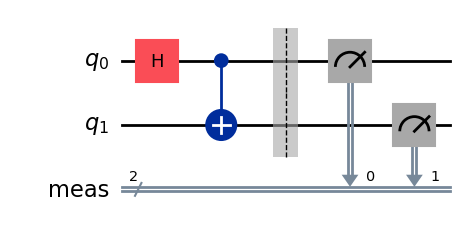

In [6]:
qc = QuantumCircuit(2) # 2 qbits
qc.h(0) # Hadamard on first qbit
qc.cx(0, 1) # cnot between first and second qbit
qc.measure_all() # State Projector Measure

print("Circuit:")
display(qc.draw(output='mpl'))
service = QiskitRuntimeService()

Selecting backend...
Running on backend: ibm_fez
Submitting job...
Probabilities 500 shots:


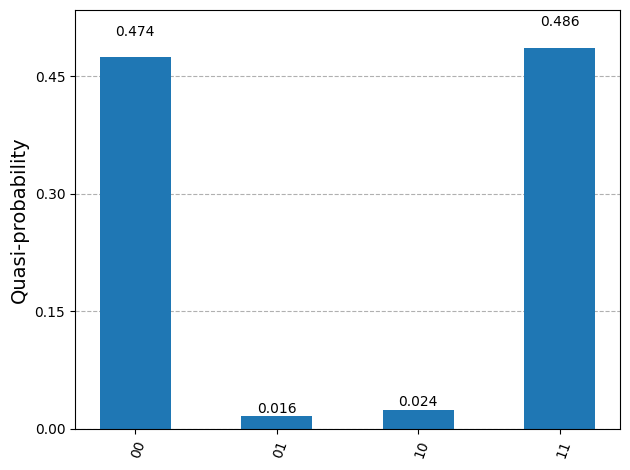

In [7]:
shots = 500

print("Selecting backend...")
backend = service.least_busy(simulator=False, operational=True) # real quantum computer
print(f"Running on backend: {backend.name}")

qc_transpiled = transpile(qc, backend=backend)
sampler = SamplerV2(backend)
job = sampler.run([qc_transpiled], shots=shots)

print("Submitting job...")
result = job.result()

counts = result[0].data.meas.get_counts()
probabilities = {state : count / shots for state, count in counts.items()}
print(f"Probabilities 500 shots:")
plot_histogram(probabilities)

### Why results differ from the simulator
While the simulator (Exercise 01) is mathematically perfect, real quantum hardware (Exercise 02) is subject to environmental interference, leading to **Quantum Noise**.

**Key factors:**
* **Decoherence**: Qubits lose their quantum state due to interaction with the environment (heat, radiation).
* **Gate Errors**: Physical operations (H, CNOT) are not 100% accurate, causing slight deviations.
* **Readout Errors**: The measurement process can sometimes misclassify a $|0\rangle$ as a $|1\rangle$ or vice-versa.

The appearance of "impossible" states like $|01\rangle$ or $|10\rangle$ in the histogram is the physical signature of a real, noisy quantum processor (NISQ).